# Diameter distribution

## Foreword
Diameter distribution analysis is the fundamental diagnostic tool for sustainable forest management (SFM) in the tropics, acting as a structural "census" that evaluates demographic health and regenerative potential. In stable, uneven-aged tropical ecosystems, this analysis typically reveals an "inverse J-shaped" curve, where a high density of small-diameter recruits ensures the future replacement of the fewer, larger canopy trees that dominate carbon stocks and biomass (Kohyama, 1993; West, 2015). By quantifying these size classes, managers can calculate the q-ratio to identify structural gaps—such as a lack of mid-sized trees—which often indicate historical over-exploitation, intense competition, or recruitment failure (Lamprecht, 1990). This structural data is critical for determining Annual Allowable Cut (AAC) quotas, ensuring that timber extraction does not exceed the forest's natural growth rate, and for protecting "large-stature" trees that Feldpausch *et al.* (2012) demonstrated are disproportionately responsible for above-ground carbon storage. Ultimately, monitoring these distributions under a Reduced Impact Logging (RIL) framework allows for the maintenance of a forest's functional resilience, biodiversity, and long-term economic viability (Putz *et al.*, 2008).

Here we present a diameter distribution analysis made for Yurumanguí's forests as a tools for assessing stand density in tropical forests based on tree thickness.

## 1. Import libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inventory_data import load_inventory

## 2. Data import

In [27]:
# Load an Excel file
df = df = load_inventory()

## 3. Data tidy
For data tidying it is important to precise on the line area, which means that it is require to count the number of plots that lie inside each forest line and calculate the area in hectares. This will help us to establish each density index in terms of hectare.


In [28]:
#The of each line in hectares
plot_size = 5000
plot_size_ha = plot_size/10000

print(f'The area of sample plots is: {plot_size} m², which means {plot_size_ha} ha.')

# counts per line
plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()
print(plot_counts)

The area of sample plots is: 5000 m², which means 0.5 ha.
Line Number
1    12
2    19
3    18
4     7
5    10
6    12
7    11
Name: Plot, dtype: int64


C:\Users\migue\AppData\Local\Temp\ipykernel_4456\4092700538.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()


In [29]:
line_area_df = plot_counts.rename('plot_count').to_frame().assign(line_area_ha=lambda x: x['plot_count'] * plot_size_ha)
print(line_area_df)

             plot_count  line_area_ha
Line Number                          
1                    12           6.0
2                    19           9.5
3                    18           9.0
4                     7           3.5
5                    10           5.0
6                    12           6.0
7                    11           5.5


## 4. Diameter distribution
Diameter distribution consist on sorting and grouping trees' DBHs in a frequencies' histogram. For this case, trees' DBH values are grouped in class intervals of 10 cm size, with an exception for those that have values higher than 200 cm which are grouped in the last interval. Once we classify the trees into each diameter class, we will estimate the basal area and volume per diameter class.

| Diameter class      | Class interval [cm] |
|:-------------------:|:-------------------:|
| I                   | 10-20               |
| II                  | 20-30               |
| III                 | 30-40               |
| IV                  | 40-50               |
| V                   | 50-60               |
| VI                  | 60-70               |
| VII                 | 70-80               |
| VIII                |80-90                |
| IX                  |90-100               |
| X                   |100-110              |
| XI                  |110-120              |
| XII                 |120-130              |
| XIII                |130-140              |
| XIV                 |140-150              |
| XV                  |150-160              |
| XVI                 |160-170              |
| XVII                |170-180              |
| XVIII               |180-190              |
| XIX                 |190-200              |
| XX                  |> 200                |

### 4.1 Diameter distribution along lines
Number of trees per diameter class is assessed for the whole area as well as per forest line. The aim of this analysis consist on observe how much mature and disturbed is the forest by counting how many thin and thick trees can we observed inside a forest area.

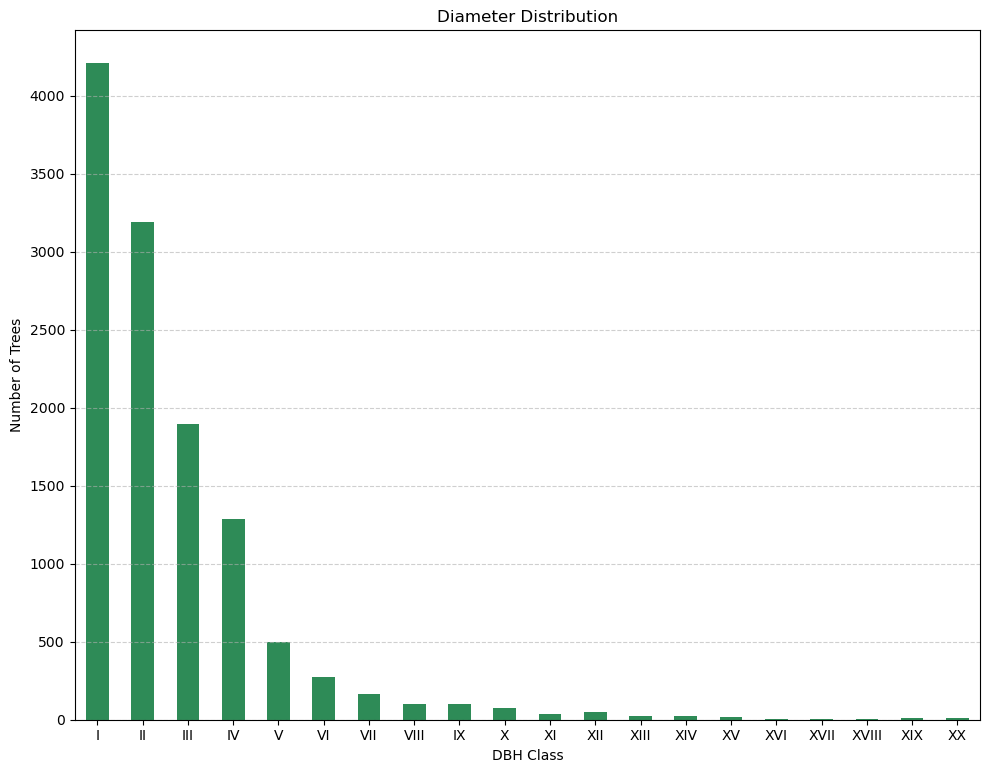

In [30]:
#Let's plot the diameter distribution
plt.figure(figsize=(10,8))
df["DBH Class"].value_counts().sort_index().plot(kind='bar', color='#2E8B57')
plt.xlabel('DBH Class')
plt.ylabel('Number of Trees')
plt.title('Diameter Distribution')
plt.tight_layout()
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Diameter distribution here illustrates a classic inverse J-shaped, which is the structural gold standard for a stable, uneven-aged tropical forest in equilibrium (Kohyama, 1993). The high frequency of individuals in the initial DBH classes (I–IV) represents a robust "regeneration bank," ensuring that as older trees die or are selectively harvested, there is a continuous supply of recruits to maintain the canopy. The smooth, exponential decline toward the larger diameter classes (X–XX) indicates a balanced q-ratio, suggesting that mortality and growth rates are synchronized across the population (Lamprecht, 1990). From a sustainable management perspective, this distribution confirms that the forest possesses high functional resilience and can support Reduced Impact Logging (RIL), provided that the harvest focuses on a limited number of the rare, high-biomass individuals in the "long tail" of the curve without compromising the overall structural integrity (Putz *et al.*, 2008).

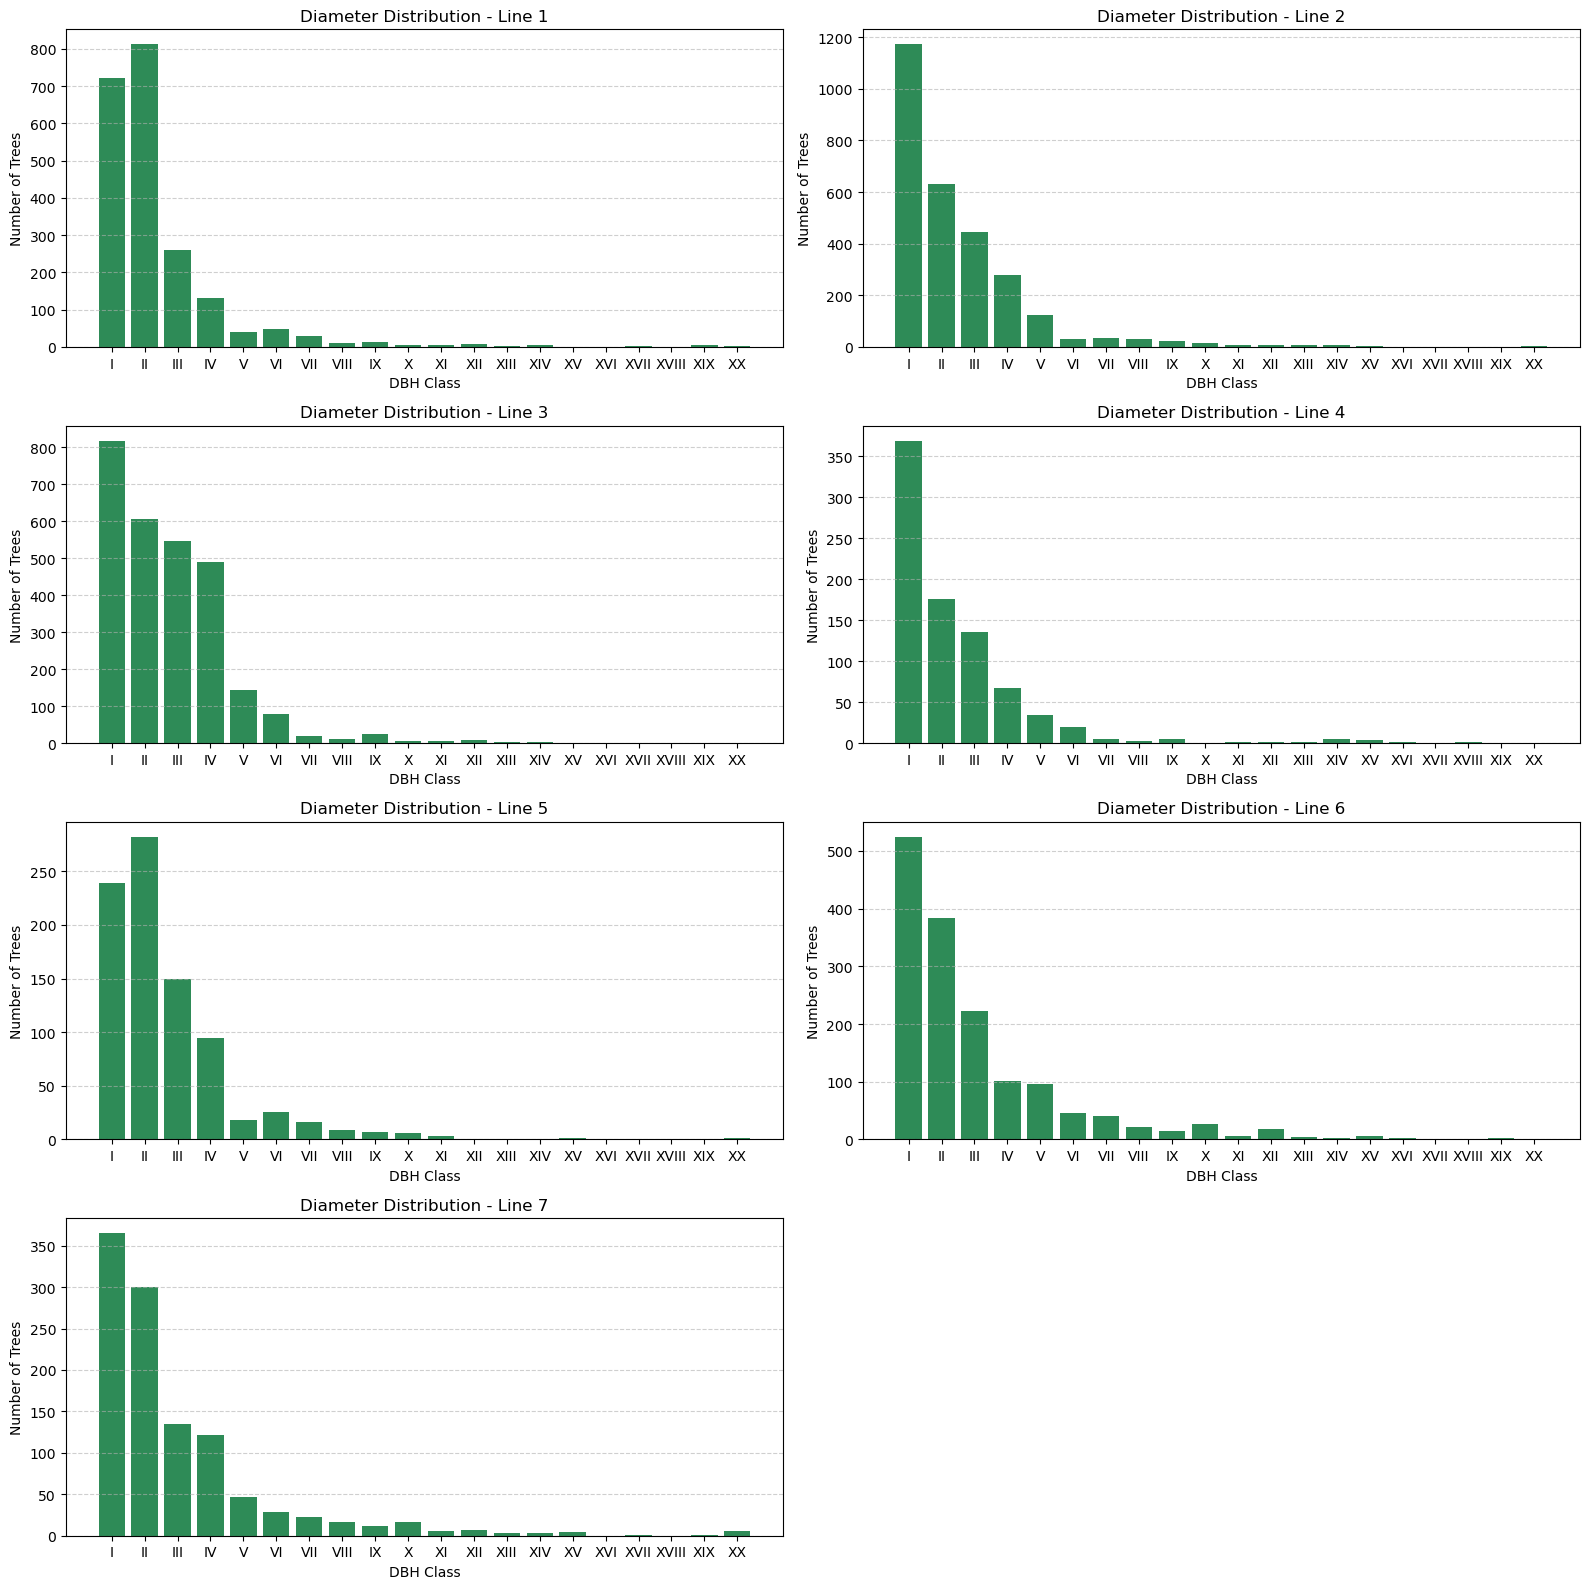

In [31]:
# Create a 4x2 matrix of subplots, one for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    dbh_class_counts = line_data["DBH Class"].value_counts().sort_index()
    
    axes[i].bar(range(len(dbh_class_counts)), dbh_class_counts.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees')
    axes[i].set_title(f'Diameter Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(dbh_class_counts)))
    axes[i].set_xticklabels(dbh_class_counts.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

Across these seven lines, the forest exhibits a consistent inverse J-shaped distribution, which indicates a healthy, self-replacing ecosystem where a large "bank" of young trees in the smaller diameter classes (I-IV) provides a steady supply of successors for the canopy. However, subtle variations between the lines reveal different localized histories; for instance, Line 1 and Line 5 show a slight deficit in the very smallest class (I) compared to class II, suggesting a recent, temporary dip in seed germination or early survival. In contrast, Line 2 shows the most aggressive recruitment curve, with over 1,100 individuals in the first class, pointing toward a highly active regeneration phase. Across all plots, the "long tail" of the distribution—representing the rare but massive trees in classes XV through XX—is maintained, which is essential for preserving the forest's structural complexity and carbon storage. From a management standpoint, the continuity of these curves across all seven samples suggests that the forest is structurally resilient enough to support selective timber extraction, provided the harvest is balanced against the natural thinning seen in the steep drop-offs between the mid-size classes.

Line 6 currently holds the highest density of mature, harvest-ready trees. While all lines follow the characteristic inverse J-shape, Line 6 stands out because it maintains a more consistent and higher frequency of individuals across the "long tail" of the distribution, specifically from DBH classes X through XVIII. In contrast, lines like Line 2 and Line 4 show a much sharper drop-off after the initial size classes, with almost no individuals reaching the larger diameter categories. Line 7 also shows some presence in the largest classes, including a notable occurrence in class XX, but Line 6 provides a broader and more reliable volume of mature timber distributed across multiple harvestable size classes. This makes Line 6 the most suitable area for immediate selective harvesting, as it contains a higher concentration of the large-stature trees that have successfully transitioned through the competitive mid-sized growth stages.

Let's do the analysis for diameter distribution per hectare.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2785790125.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()


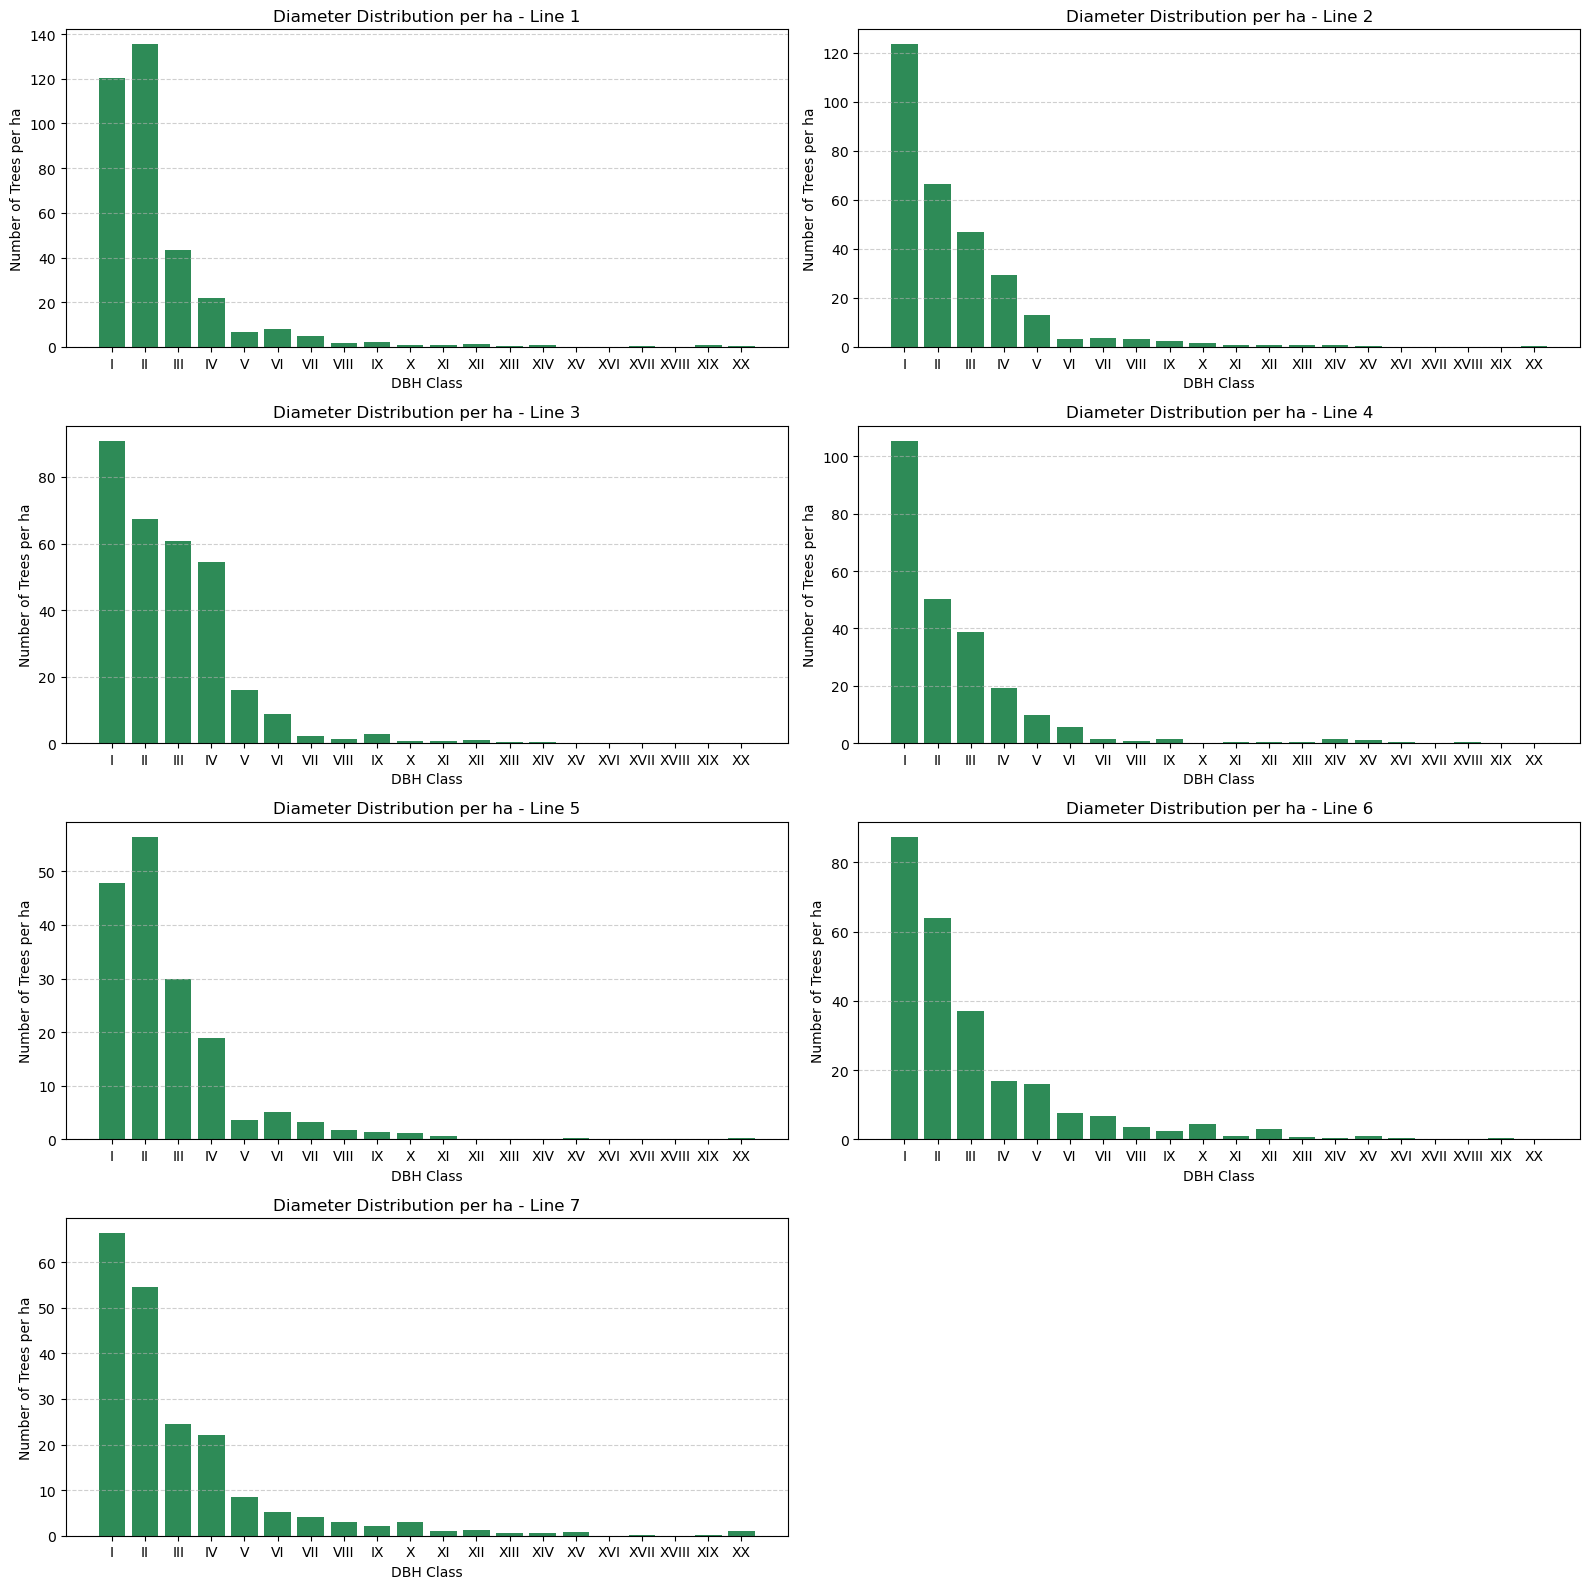

In [32]:
# Create a 4x2 matrix of subplots, one for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    dbh_class_counts = line_data["DBH Class"].value_counts().sort_index()

    # Compute per-hectare counts (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        dbh_per_ha = dbh_class_counts / area
    else:
        # if area is missing or zero, set NaN to avoid division by zero
        dbh_per_ha = pd.Series([np.nan] * len(dbh_class_counts), index=dbh_class_counts.index)

    axes[i].bar(range(len(dbh_per_ha)), dbh_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees per ha')
    axes[i].set_title(f'Diameter Distribution per ha - Line {line_num}')
    axes[i].set_xticks(range(len(dbh_per_ha)))
    axes[i].set_xticklabels(dbh_per_ha.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

Diameter distribution per hectare across seven sampling lines provide a standardized look at the forest's density and structure. Overall, the forest exhibits a highly functional, uneven-aged structure characterized by the inverse J-shaped curve, though the per-hectare scaling reveals that Line 1 and Line 2 are significantly more "stocked" or dense than the others, particularly in the sapling stages (over 120 trees per hectare in the first classes). Line 5 presents a distinct "bell-shaped" irregularity in its initial classes (Class II being more populous than Class I), which signals a localized suppression of the youngest recruits that may require silvicultural intervention to ensure future timber volume. Across the board, the extremely low density of trees in classes X through XX (often fewer than 2–5 trees per hectare) highlights the rarity of large-diameter individuals, emphasizing that any sustainable harvest plan must be strictly selective to avoid depleting the canopy's structural and carbon-sequestration "anchors."

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2641003323.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Line Number')['DBH [cm]']
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2641003323.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(x=[group.values for name, group in grouped],


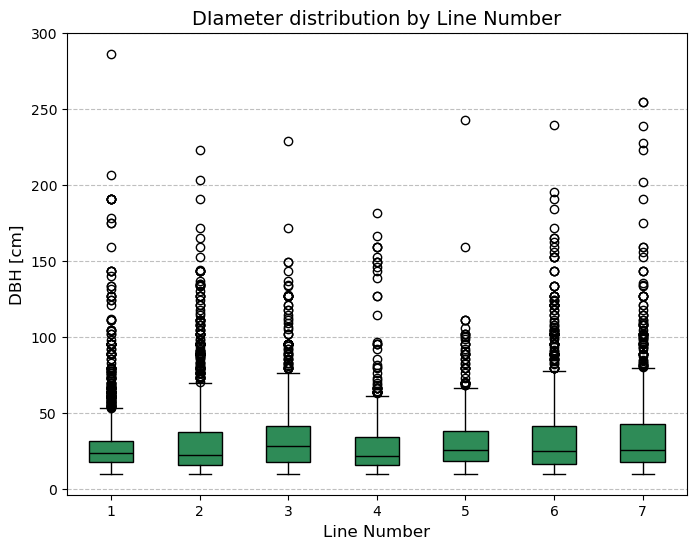

In [33]:
# Group our dataset with our 'Group' variable
grouped = df.groupby('Line Number')['DBH [cm]']

# Init a figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Create the plot with different colors for each group
boxplot = ax.boxplot(x=[group.values for name, group in grouped],
                     labels=grouped.groups.keys(),
                     patch_artist=True,
                     medianprops={'color': 'black'}
                    )

# Assign colors to each box in the boxplot
for box, color in zip(boxplot['boxes'], ['#2E8B57'] * len(boxplot['boxes'])):
    box.set_facecolor(color)
    
# Add a title and axis label
ax.set_title('DIameter distribution by Line Number', fontsize=14)

ax.set_xlabel('Line Number', fontsize=12)
ax.set_ylabel('DBH [cm]', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.8)
# Display it
plt.show()

Boxplot provides a clear visualization of the diameter distribution across the seven lines, highlighting the immense structural variability typical of tropical forests. While the median diameter across all lines remains consistently low (below 30 cm), the presence of numerous outliers extending up to 280 cm illustrates the "long tail" of the distribution. Line 3 shows the highest median and a broader interquartile range, indicating a more mature stand with a greater concentration of mid-sized trees. Conversely, Line 1 has the most compressed box, suggesting a younger or more dense population dominated by small stems, yet it also contains the single largest individual outlier in the entire dataset (near 290 cm). The high density of outliers across all lines—particularly in Line 6 and Line 7—is a positive indicator for sustainable management, as it confirms the presence of "mega-trees" that serve as vital seed sources and carbon reservoirs.

While most lines have a median DBH below 30 cm, Line 7 stands out because its interquartile range (the green box) and its upper whisker reach the highest points on the scale, indicating that its "typical" large trees are bigger than those in other lines. Furthermore, Line 7 shows an exceptionally high density of outliers—individual trees—extending from 80 cm to over 250 cm. Line 6 follows closely, displaying a very thick "smear" of outliers between 80 cm and 170 cm, suggesting a high volume of timber in those specific commercial size classes.

In contrast, Line 3 has the highest median diameter, meaning it has the most "mature" average population, but it lacks the extreme giants found in Lines 6 and 7. For a management plan, Line 7 would be prioritized for its high-volume individuals, while Line 3 would be noted for having the most consistent stock of mid-to-large timber.

### 4.2 Basal area
On parallelt to the diameter distribution, here we estimate how much dominant can be a diameter class by calculating the total basal area per diameter class. In terms of forest management, this is a key indicator for deciding which trees could be cut and which could be kept as remnants when an individual thinning cut must be applied.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\1472629665.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\1472629665.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\1472629665.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

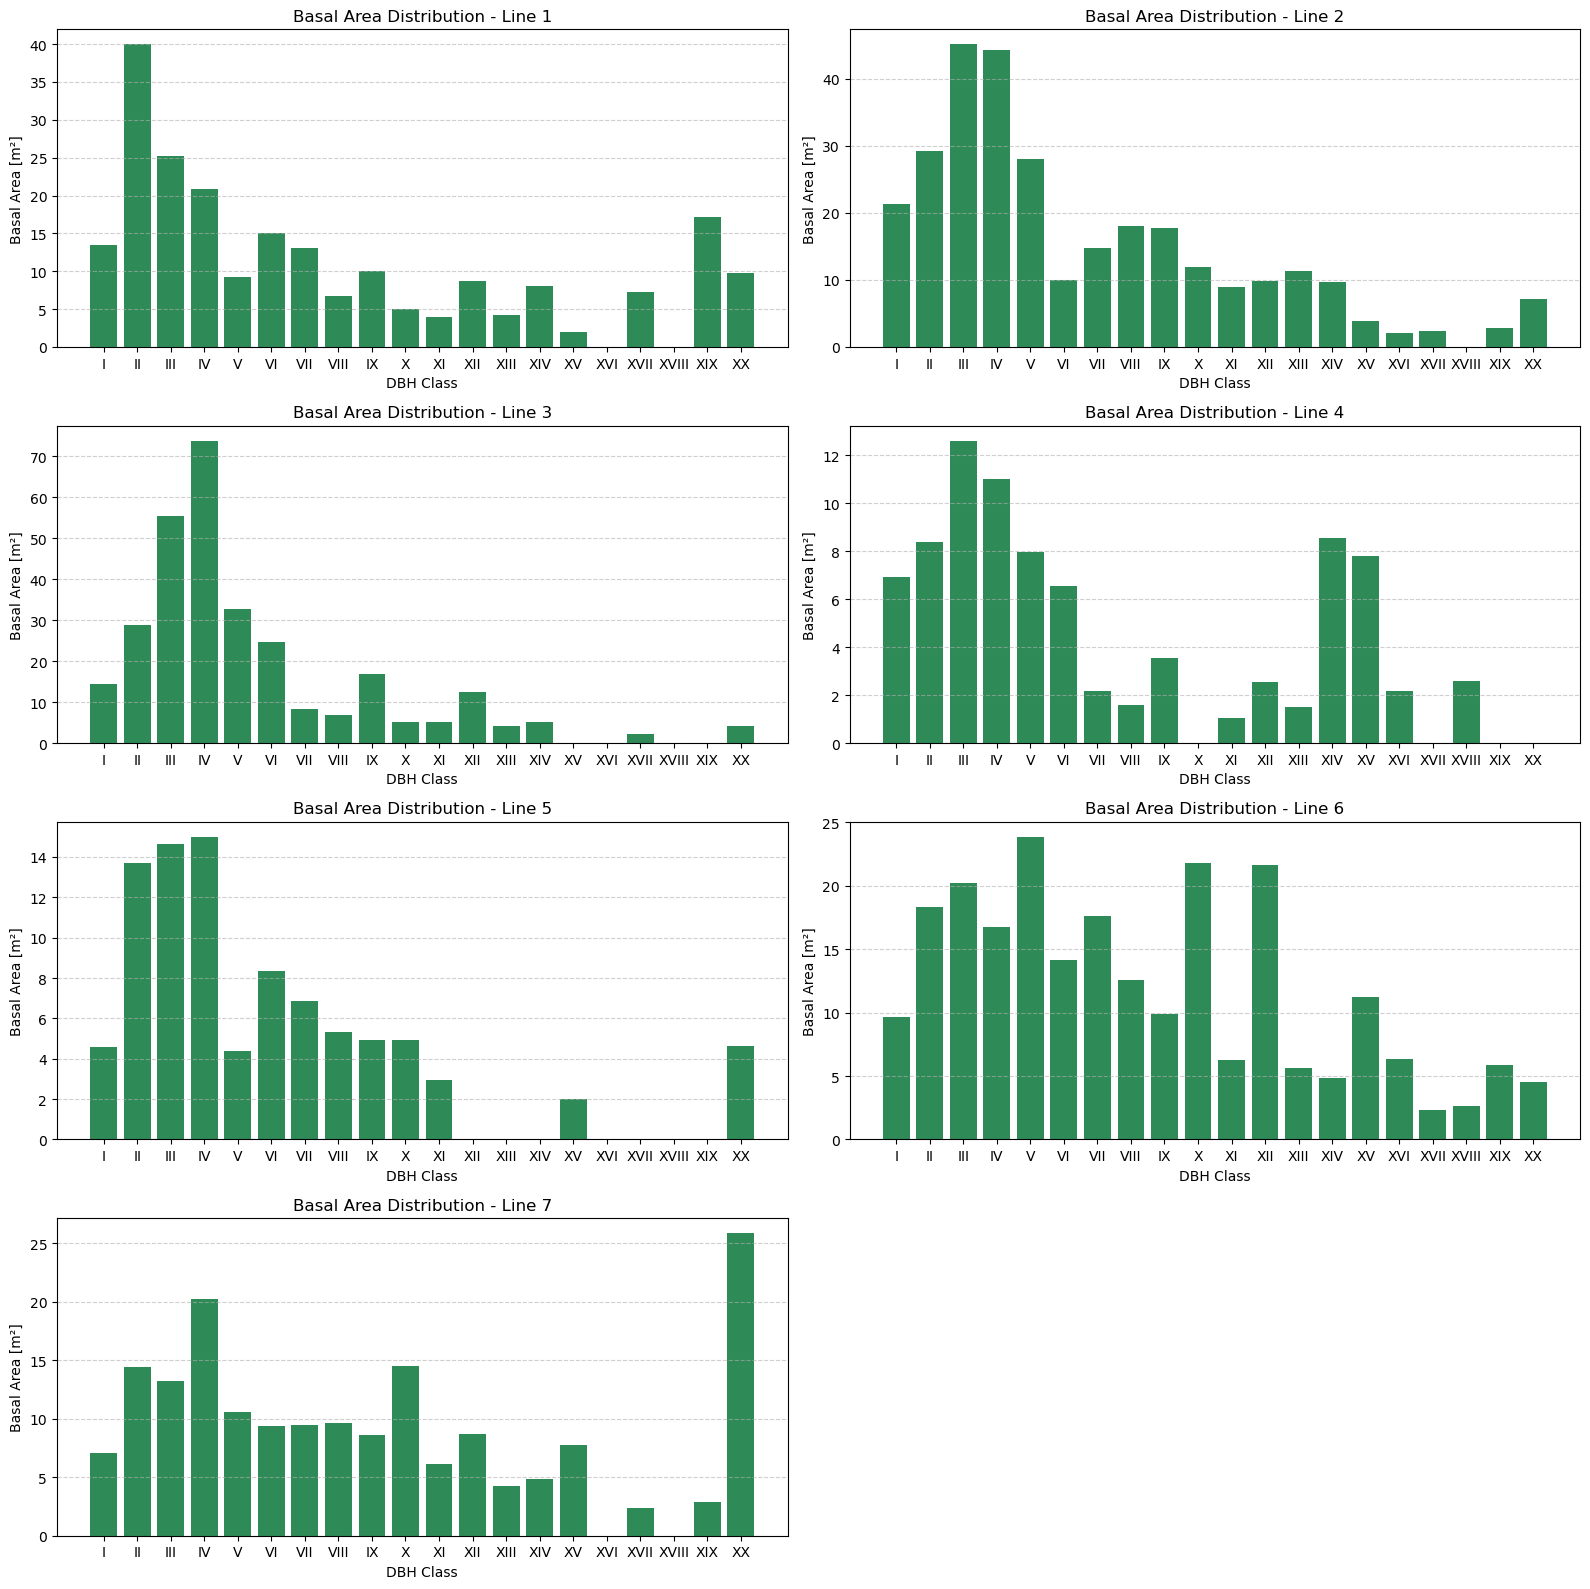

In [34]:
# Create a 4x2 matrix of subplots for Basal Area by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().sort_index()
    
    axes[i].bar(range(len(basal_area_by_class)), basal_area_by_class.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area [m²]')
    axes[i].set_title(f'Basal Area Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(basal_area_by_class)))
    axes[i].set_xticklabels(basal_area_by_class.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

The basal area distribution across these seven lines reveals where the forest’s physical wood volume and biomass are concentrated, shifting the focus from tree counts to actual occupancy of space. While most lines, particularly Line 2 and Line 3, show a massive accumulation of basal area in the mid-size classes (III–V), Line 1 and Line 7 are structurally dominated by "mega-trees" in Class XX, which contribute a disproportionate amount of total wood volume despite their low numerical frequency. Line 3 stands out as the most biomass-heavy site, reaching peaks of over 70 m², suggesting a highly productive or older-growth stage compared to the more distributed volumes in Line 5 and Line 6. From a management perspective, these charts identify the specific diameter classes where the forest's "standing capital" is highest, indicating that while the mid-sized trees represent future growth potential, the large-diameter spikes in the "tail" represent the primary carbon reservoirs and immediate timber value that must be managed with extreme selectivity to maintain forest equilibrium.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\766269596.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\766269596.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().reindex(dbh_categories, fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\766269596.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

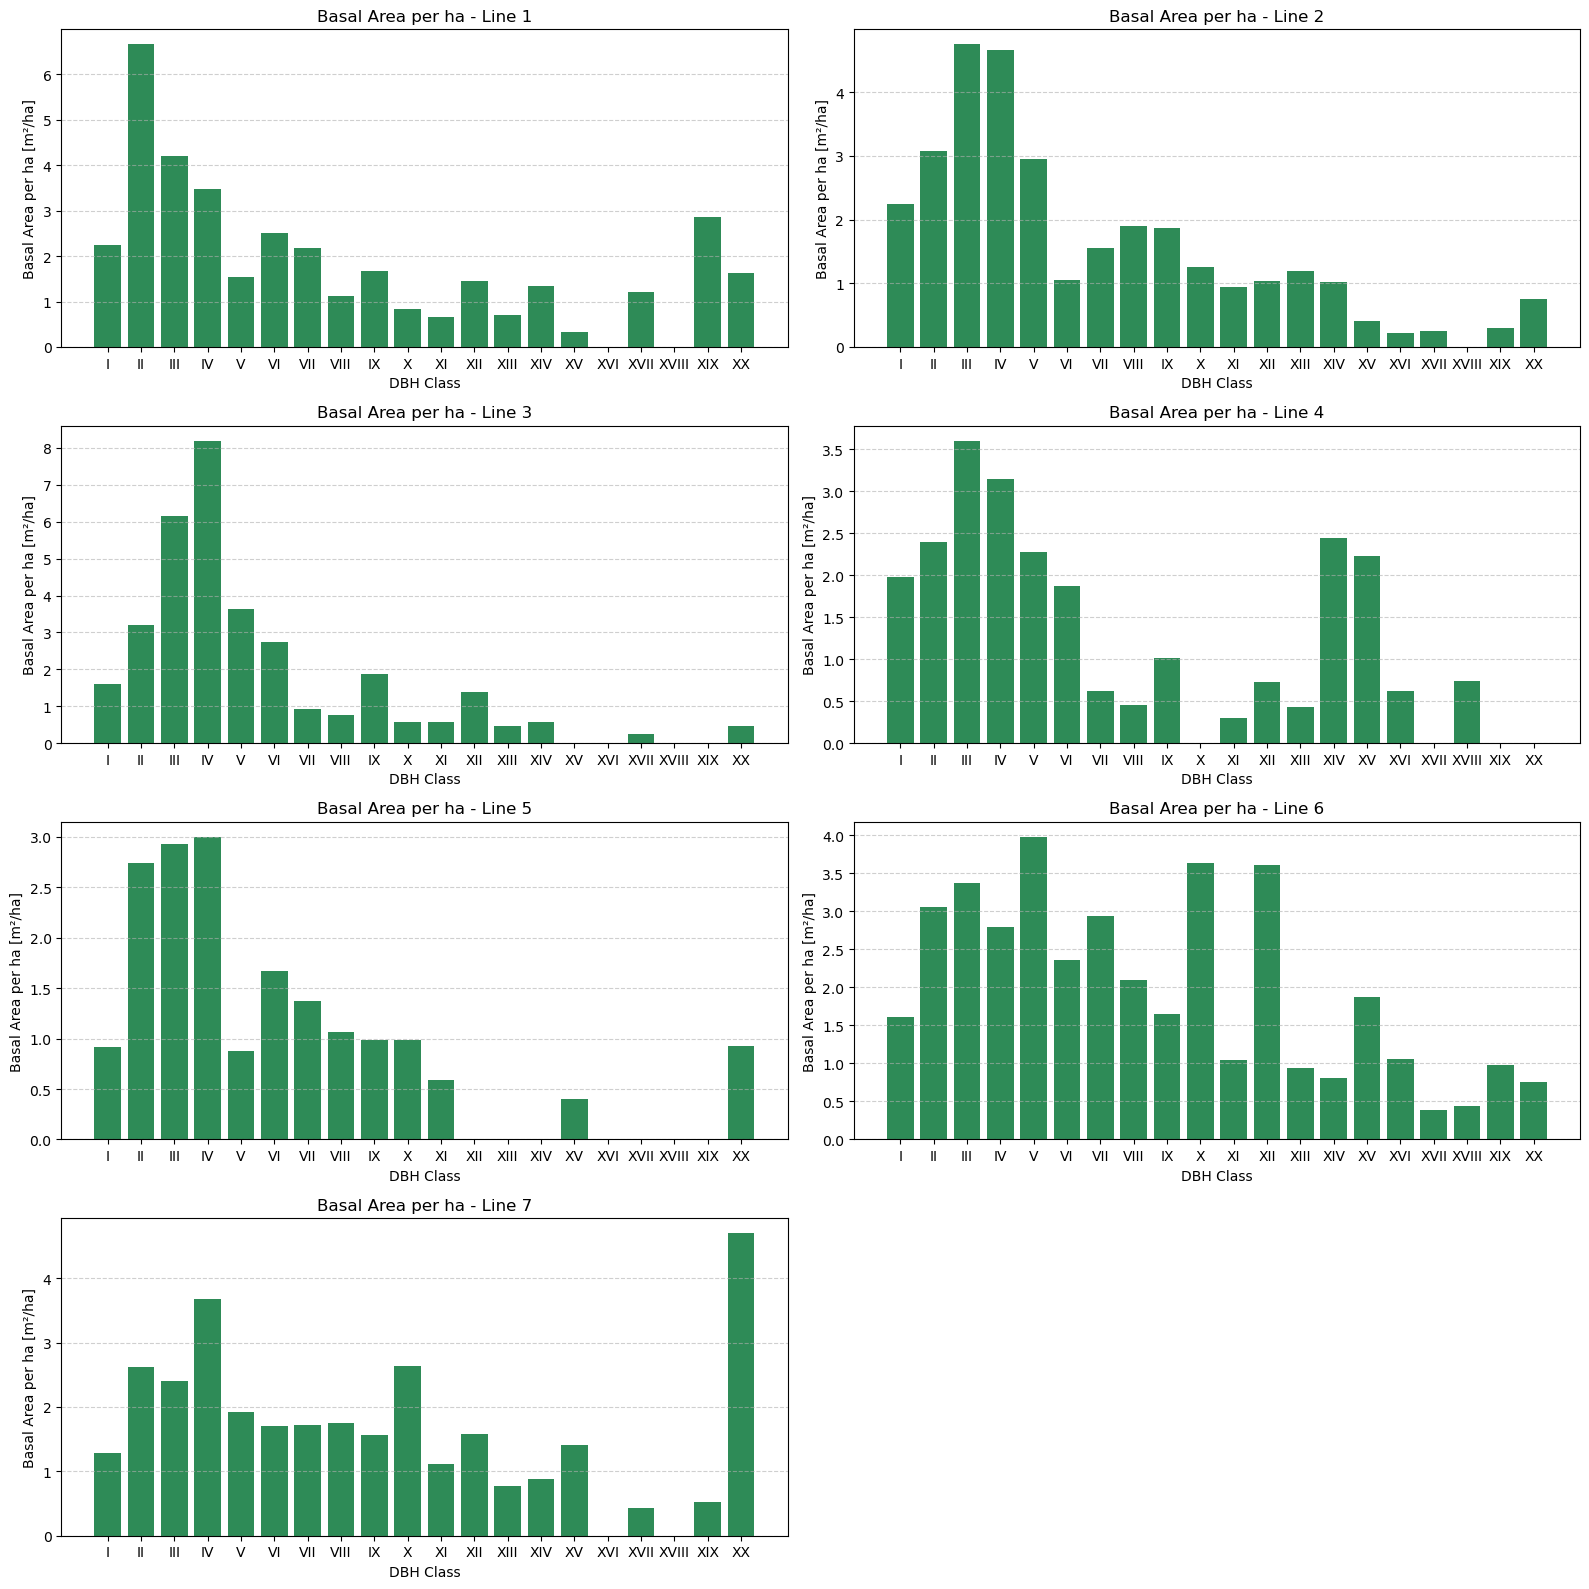

In [35]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Basal area [m2]"].sum().reindex(dbh_categories, fill_value=0)

    # Compute per-hectare basal area (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = basal_area_by_class / area
    else:
        ba_per_ha = pd.Series([np.nan] * len(basal_area_by_class), index=basal_area_by_class.index)

    axes[i].bar(range(len(ba_per_ha)), ba_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area per ha [m²/ha]')
    axes[i].set_title(f'Basal Area per ha - Line {line_num}')
    axes[i].set_xticks(range(len(ba_per_ha)))
    axes[i].set_xticklabels(ba_per_ha.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


The Basal Area per hectare charts provide a standardized metric of forest occupancy, revealing that while the youngest trees are most numerous, the bulk of the forest's actual biomass and physical standing stock is concentrated in the mid-to-large size classes. Line 3 demonstrates the highest localized productivity, with Class IV reaching an impressive density of over 8 m²/ha, indicating a site nearing a mature "plateau" of wood accumulation. In contrast, Line 7 displays a starkly different structural priority, where the single largest diameter class (XX) accounts for the highest basal area per hectare (nearly 5 m²/ha), showcasing how a few massive "legacy trees" can outweigh the biological occupancy of hundreds of smaller saplings. Across all lines, the persistent peaks in classes III–V represent the "future of the forest," as these trees currently hold the most competitive space and will eventually migrate into the larger, high-carbon-storage classes. From a sustainability standpoint, these per-hectare values are essential for ensuring that selective logging removes only a fraction of the total basal area, thereby maintaining the forest's microclimate and its long-term capacity for carbon sequestration.

Based on the basal area per hectare charts, Line 5 exhibits the most significant "gaps" in its distribution, with a complete absence of individuals in classes XII through XIV and nearly all classes between XVI and XIX. These structural voids are critical indicators of lower resilience, suggesting a history of localized disturbance—such as past selective logging or severe weather events—that effectively "erased" specific age cohorts or halted recruitment for a period of several decades. Unlike the more continuous distributions in Line 2 or Line 6, these gaps create a demographic bottleneck where there are no mid-to-large transition trees available to eventually replace the current canopy giants. From a sustainable management perspective, Line 5 would be prioritized for conservation or "enrichment planting" rather than harvesting, as its broken structure needs time to recover its full successional sequence and ensure long-term carbon and timber stability.

In [36]:
# Sum basal area by line and only for the two target species, then convert to per-hectare using line_area_ha
basal_area_sum = (
    df.groupby(['Line Number'])['Basal area [m2]']
      .sum()
)
      
# Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# Display the result
print('Basal area (m²/ha) by Line:')
display(basal_area_ha_by_line)

Basal area (m²/ha) by Line:


C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2884080485.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Line Number'])['Basal area [m2]']


Line Number
1    36.617425
2    31.410743
3    33.397339
4    24.859179
5    18.447296
6    39.362195
7    32.690184
dtype: float64

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2935203786.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_sum = df.groupby('Line Number')['Basal area [m2]'].sum()


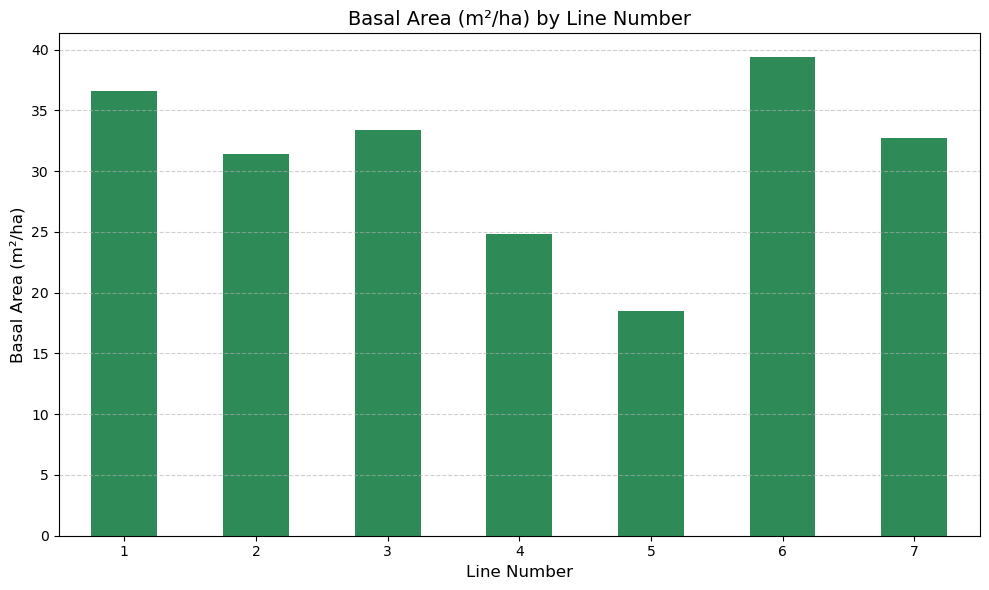

In [37]:
# 2. Sum basal area by line
basal_area_sum = df.groupby('Line Number')['Basal area [m2]'].sum()

# 3. Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# --- CHARTING SECTION ---

# 4. Clean the data for plotting: Convert index to integer and sort
# We use .dropna() in case some lines had no target species
plot_data = basal_area_ha_by_line.dropna().sort_index()
plot_data.index = plot_data.index.astype(int)

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color='#2E8B57')

# Formatting labels and titles
plt.title('Basal Area (m²/ha) by Line Number', fontsize=14)
plt.xlabel('Line Number', fontsize=12)
plt.ylabel('Basal Area (m²/ha)', fontsize=12)
plt.xticks(rotation=0)  # Keeps the line numbers horizontal for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The bar chart illustrating Basal Area ($m^2$/ha) by Line Number reveals significant variations in wood volume and site productivity across the sampled area. Line 6 exhibits the highest stocking level, reaching approximately 39.36 $m^2$/ha, followed closely by Line 1, which suggests these areas contain the most mature stands or a higher density of large-diameter trees. In contrast, Line 5 shows the lowest basal area at roughly 18.44 $m^2$/ha, nearly 50% less than the leading lines; this disparity, coupled with the "gaps" identified in previous distribution analyses, confirms that Line 5 is currently in a lower biomass state, likely due to past disturbances or recruitment bottlenecks. For sustainable management, these totals establish the baseline "standing capital," indicating that while Lines 1 and 6 hold the greatest immediate carbon and timber value, Line 5 represents a critical area for recovery where harvesting should be avoided to allow for biomass accumulation.

The general analysis of the basal area across all seven lines reveals a forest with high structural heterogeneity, where the total standing biomass varies significantly by location. The forest maintains an average basal area of approximately 30.5 m²/ha, a figure typical of well-stocked tropical secondary or primary forests. Line 6 and Line 1 are the primary "carbon anchors" of the study area, showing the highest maturity and wood volume, likely due to a higher concentration of large-diameter legacy trees. Conversely, the significant drop-off in Line 5—which holds less than half the basal area of Line 6—points to a localized "biomass deficit" caused by either past intensive harvesting or natural gap dynamics that have not yet reached the building phase. From a sustainable management perspective, this distribution suggests that while the forest as a whole is productive, harvesting activities should be strategically concentrated in high-volume areas like Line 6, while Line 5 should be excluded from the current cutting cycle to allow its basal area to recover to the landscape average.

### 4.3 Log volume

As done before, the volume per diameter class is calculated and estimated for observing which diameter class can have thmost amount of log volume and biomass.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2486615043.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2486615043.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2486615043.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

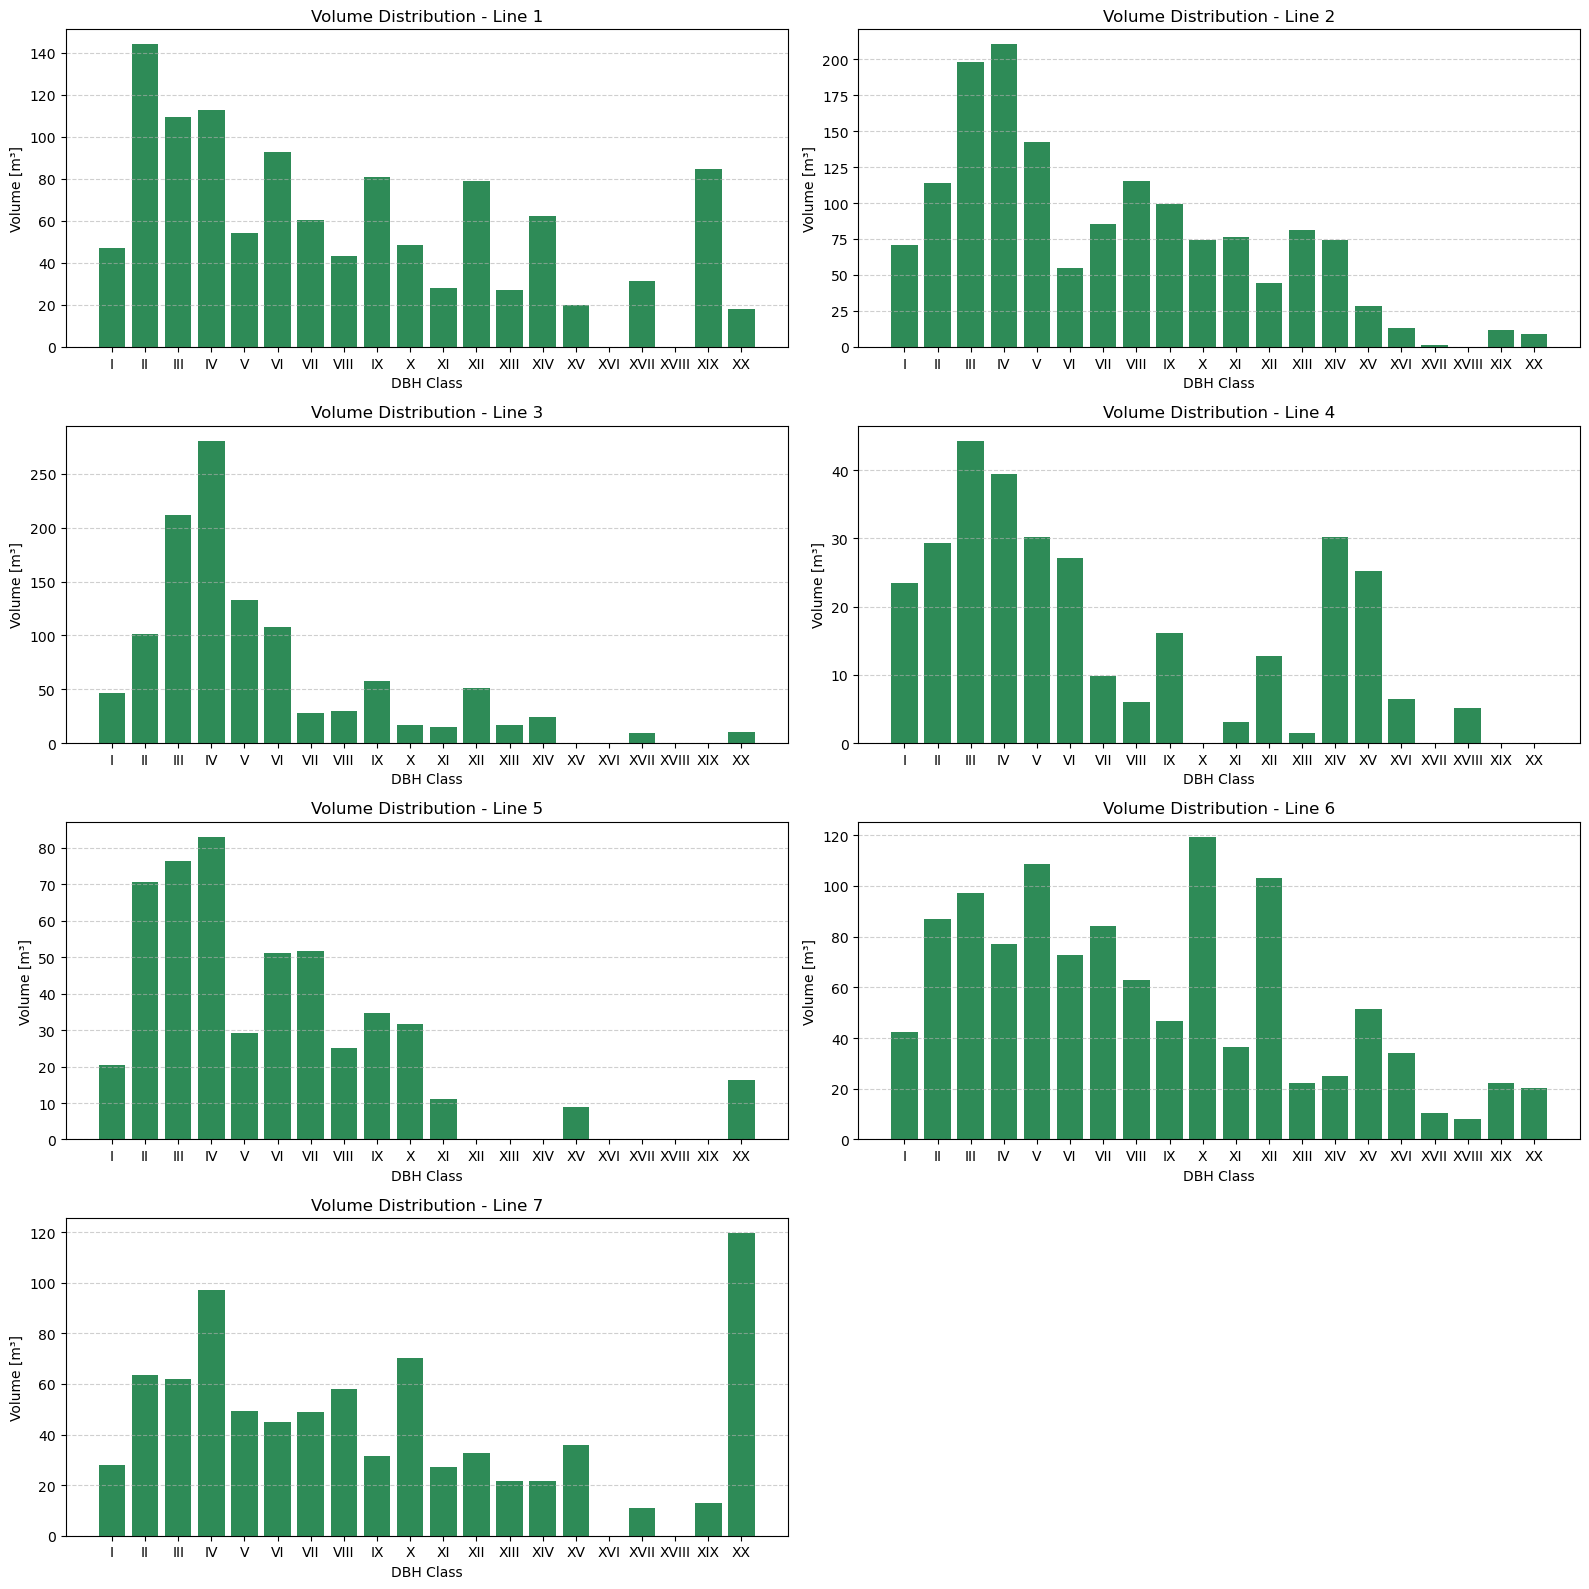

In [38]:
# Create a 4x2 matrix of subplots for Volume by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().sort_index()
    
    axes[i].bar(range(len(basal_area_by_class)), basal_area_by_class.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume [m³]')
    axes[i].set_title(f'Volume Distribution - Line {line_num}')
    axes[i].set_xticks(range(len(basal_area_by_class)))
    axes[i].set_xticklabels(basal_area_by_class.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

The Volume Distribution charts provide the most critical data for economic and sustainability planning, as they translate the forest's structural measurements into three-dimensional wood quantity ($m^3$). While the previous tree-count charts were dominated by small saplings, these volume charts show that the vast majority of the forest's "standing stock" is held in the mid-to-large diameter classes, with Line 3 exhibiting the highest overall productivity and a massive volume peak of nearly 280 $m^3$ in Class IV. Line 7 displays a unique "bi-modal" structure where volume is concentrated both in the mid-size recruits and a singular, massive spike in Class XX, illustrating the extreme economic and ecological weight of legacy trees. In contrast, Lines 4 and 5 show much lower total volumes and significant gaps in the larger size classes, indicating areas that are currently volume-poor and should be prioritized for recovery. For sustainable management, this analysis identifies the specific diameter ranges—generally between classes III and VI—where the forest is currently producing the most wood, allowing managers to target selective harvests that optimize yield without depleting the rare, high-volume individuals that serve as the forest's primary carbon and seed reservoirs.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2940489913.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2940489913.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().reindex(dbh_categories, fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2940489913.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

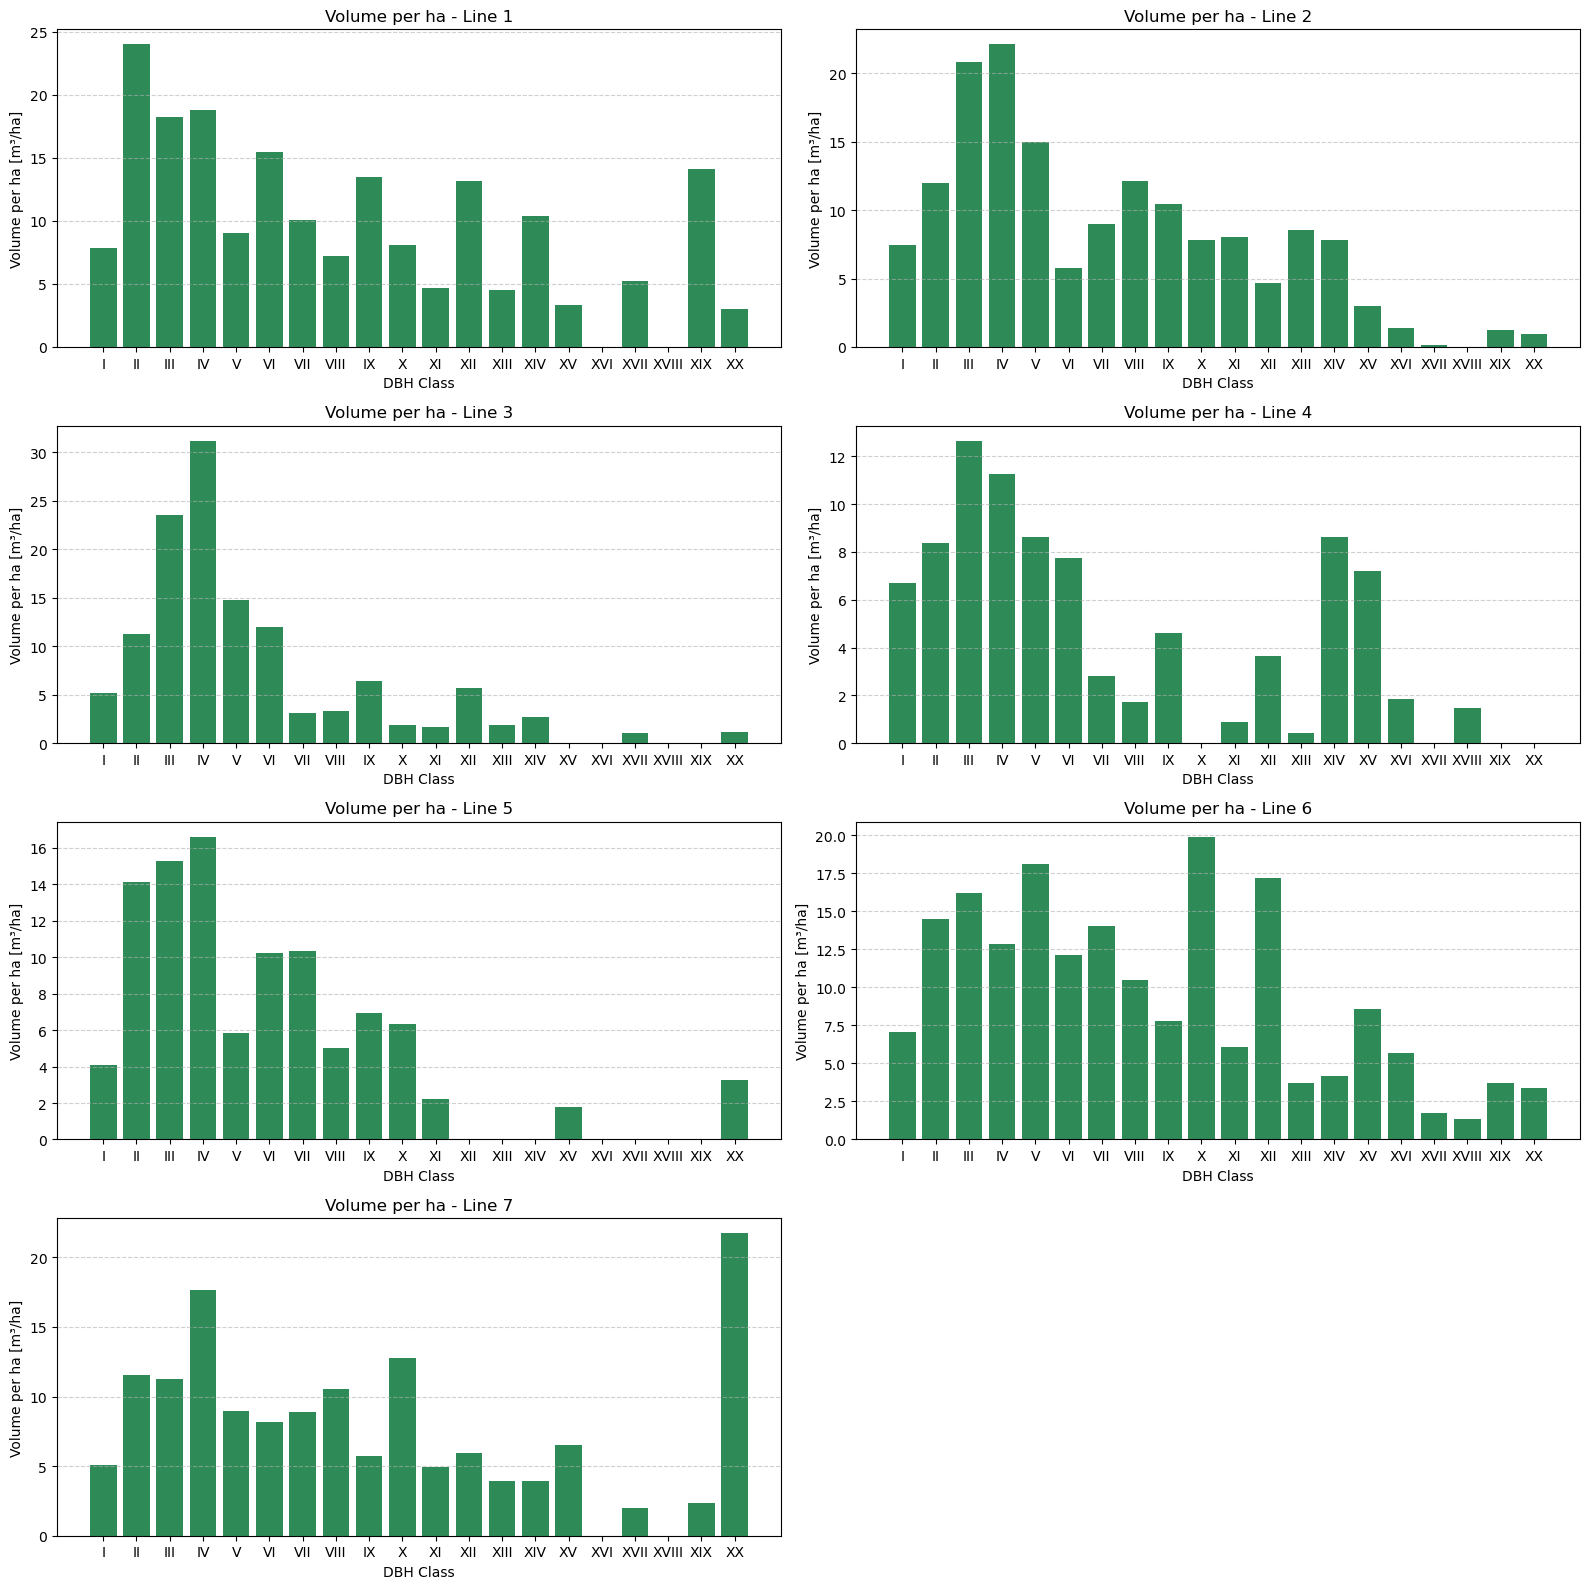

In [39]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

for i, line_num in enumerate(range(1, 8)):
    line_data = df[df["Line Number"] == line_num]
    basal_area_by_class = line_data.groupby("DBH Class")["Volume [m3]"].sum().reindex(dbh_categories, fill_value=0)

    # Compute per-hectare basal area (handle missing/zero area)
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = basal_area_by_class / area
    else:
        ba_per_ha = pd.Series([np.nan] * len(basal_area_by_class), index=basal_area_by_class.index)

    axes[i].bar(range(len(ba_per_ha)), ba_per_ha.values, color='#2E8B57')
    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume per ha [m³/ha]')
    axes[i].set_title(f'Volume per ha - Line {line_num}')
    axes[i].set_xticks(range(len(ba_per_ha)))
    axes[i].set_xticklabels(ba_per_ha.index, rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# Hide the last empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()


The Volume per hectare charts standardize the forest's productivity, revealing how much standing timber is actually available across the landscape. While the initial diameter distribution (first image) showed a high density of small saplings, these volume metrics prove that Line 3 is the most physically productive area, with Class IV reaching a peak of over 30 $m^3/ha$, indicating a high-density "pole" stage. Line 7 presents a stark contrast where the single largest diameter class (XX) holds the most volume per hectare (over 20 $m^3/ha$), demonstrating that a few "legacy" trees can hold more wood than dozens of smaller ones combined. Conversely, Lines 4 and 5 show much lower overall volume concentrations and significant gaps in the mid-to-large classes, identifying them as areas with limited immediate timber potential. Collectively, these charts indicate that while the forest is successfully regenerating, its economic and carbon "wealth" is highly localized, requiring a selective harvest approach that protects high-volume legacy trees in Line 7 while focusing growth management on the high-productivity mid-classes in Line 3.

Based on the volume per hectare charts, Line 5 and Line 7 exhibit the most "unbalanced" distributions, signaling a high risk for future canopy collapse and structural instability. Line 5 suffers from a severe demographic "bottleneck," with total volume voids in the mid-to-large classes (XII–XIV and XVI–XIX); this missing middle means that when the current older trees die, there are no transition-sized trees ready to recruit into the canopy, potentially leading to large, permanent gaps. Line 7, while holding significant volume, is dangerously "top-heavy," with its primary volume concentrated in a few massive trees in Class XX ($>20$ $m^3/ha$) and a relatively hollow mid-section. This structure creates a high-risk scenario where the natural death or harvesting of just one or two "legacy" individuals would result in a disproportionate loss of the forest's total biomass and protective cover. In a sustainable management context, these lines would require a "no-cut" policy or active restoration to fill the structural gaps, as their current lack of a continuous volume gradient makes them far more vulnerable to environmental stressors compared to the more evenly distributed stock seen in Line 2 or Line 6.

C:\Users\migue\AppData\Local\Temp\ipykernel_4456\2295983738.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_sum = df.groupby('Line Number')['Volume [m3]'].sum()


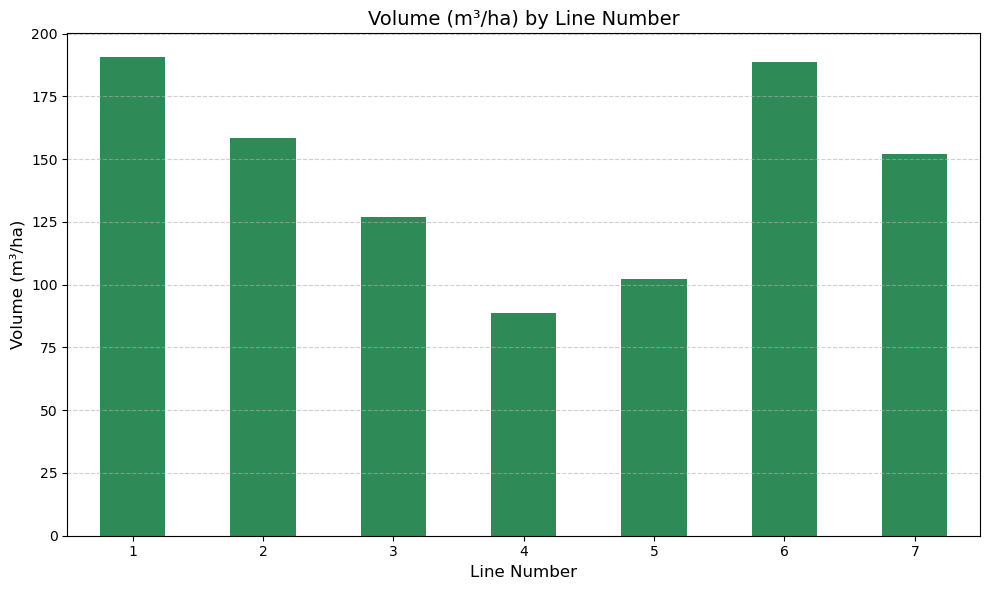

In [40]:
# 2. Sum volume by line
volume_sum = df.groupby('Line Number')['Volume [m3]'].sum()

# 3. Convert to per-hectare
volume_ha_by_line = volume_sum.div(line_area_ha, axis=0)

# --- CHARTING SECTION ---

# 4. Clean data: Convert index to integer, sort, and drop empty values
plot_data_vol = volume_ha_by_line.dropna().sort_index()
plot_data_vol.index = plot_data_vol.index.astype(int)

# 5. Create the Bar Chart
plt.figure(figsize=(10, 6))
plot_data_vol.plot(kind='bar', color='#2E8B57')

# Formatting labels and titles
plt.title('Volume (m³/ha) by Line Number', fontsize=14)
plt.xlabel('Line Number', fontsize=12)
plt.ylabel('Volume (m³/ha)', fontsize=12)
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Volume per hectare ($m^3$/ha) by Line Number serves as the definitive economic and ecological summary of the forest's productivity across the landscape. Line 1 and Line 6 are the clear "volume leaders," both surpassing 185 $m^3$/ha, which categorizes them as high-density stands with significant immediate potential for carbon sequestration or selective harvesting. In contrast, Line 4 holds the lowest volume at approximately 88 $m^3$/ha, indicating a younger or more heavily disturbed stand that currently lacks the biomass density of its neighbors. This spatial variation is critical for management: while the forest average sits around 145 $m^3$/ha, the high concentration in Line 6 compared to the deficit in Line 4 proves that a "one-size-fits-all" harvest approach would be unsustainable. Instead, these totals suggest that any management plan should focus on protecting the lower-volume lines (4 and 5) to allow for biomass accumulation, while utilizing the surplus in the higher-volume lines (1 and 6) to meet sustainability goals.

This final analysis of the forest's volume per hectare confirms a high degree of spatial and structural diversity, with an average standing stock of approximately 145 $m^3/ha$ across the study area. Line 1 and Line 6 represent the forest's most mature and volume-dense sections, both exceeding 185 $m^3$/ha, which indicates they are the primary reservoirs for carbon storage and high-value timber. Conversely, Line 4 holds less than half that volume (88 $m^3/ha$), highlighting a significant localized deficit that likely stems from past disturbances or slower growth conditions. When viewed alongside the diameter distributions, it is clear that while the forest is successfully regenerating in its smaller classes, its actual "wood wealth" is concentrated in specific lines and a few massive individuals. For a sustainable management plan, this means that any selective harvesting should be strategically limited to the high-volume surplus of Lines 1 and 6, while lower-volume areas like Line 4 must be strictly protected to allow their biomass to reach the landscape average.

With all of this in mind, what would you do as a forest manager?

## References

Feldpausch, T. R., Lloyd, J., Lewis, S. L., Brienen, R. J. W., Gloor, M., Monteagudo Mendoza, A., Lopez-Gonzalez, G., Banin, L., Abu Salim, K., Affum-Baffoe, K., Alexiades, M., Almeida, S., Amaral, I., Andrade, A., Aragão, L. E. O. C., Araujo Murakami, A., Arets, E. J. M. M., Arroyo, L., Aymard C., G. A., Baker, T. R., Bánki, O. S., Berry, N. J., Cardozo, N., Chave, J., Comiskey, J. A., Alvarez, E., de Oliveira, A., Di Fiore, A., Djagbletey, G., Domingues, T. F., Erwin, T. L., Fearnside, P. M., França, M. B., Freitas, M. A., Higuchi, N., E. Honorio C., Iida, Y., Jiménez, E., Kassim, A. R., Killeen, T. J., Laurance, W. F., Lovett, J. C., Malhi, Y., Marimon, B. S., Marimon-Junior, B. H., Lenza, E., Marshall, A. R., Mendoza, C., Metcalfe, D. J., Mitchard, E. T. A., Neill, D. A., Nelson, B. W., Nilus, R., Nogueira, E. M., Parada, A., Peh, K. S.-H., Pena Cruz, A., Peñuela, M. C., Pitman, N. C. A., Prieto, A., Quesada, C. A., Ramírez, F., Ramírez-Angulo, H., Reitsma, J. M., Rudas, A., Saiz, G., Salomão, R. P., Schwarz, M., Silva, N., Silva-Espejo, J. E., Silveira, M., Sonké, B., Stropp, J., Taedoumg, H. E., Tan, S., ter Steege, H., Terborgh, J., Torello-Raventos, M., van der Heijden, G. M. F., Vásquez, R., Vilanova, E., Vos, V. A., White, L., Willcock, S., Woell, H., and Phillips, O. L. (2012). Tree height integrated into pantropical forest biomass estimates. *Biogeosciences, 9*(8) 3381–3403, [https://doi.org/10.5194/bg-9-3381-2012](https://doi.org/10.5194/bg-9-3381-2012).

Kohyama, T. (1993). Size-structured tree populations in gap-dynamic forest--the forest architecture hypothesis for the stable coexistence of species. *The Journal of Ecology, 81*(1), 131. [doi:10.2307/2261230](https://doi.org/10.2307/2261230)

Lamprecht, H. (1990). *Silvicultura en los trópicos: Los ecosistemas forestales y sus especies arbóreas; posibilidades y métodos para un aprovechamiento sostenido*. Deutsche Gesellschaft für Zusammenarbeit (GTZ) GmbH. Rosdorf: TZ-Verl.-Ges. ISBN: 3-88085-440-8.

Putz, F. E., Sist, P., Fredericksen, T., & Dykstra, D. (2008). Reduced-impact logging: Challenges and opportunities. *Forest Ecology and Management, 256*(7), 1427–1433. [doi:10.1016/j.foreco.2008.03.036](https://doi.org/10.1016/j.foreco.2008.03.036)

West, P. W. . (2015). *Tree and forest measurement*. Cham: Springer International Publishing.